In [1]:
import sys
import os

# Remove cached modules
if 'utils.lab_utils' in sys.modules:
    del sys.modules['utils.lab_utils']
if 'utils' in sys.modules:
    del sys.modules['utils']

import cv2
import matplotlib.pyplot as plt
import numpy as np


In [2]:
from skimage.color import rgb2hsv
from utils.lab_utils import apply_hsv_threshold, apply_rgb_threshold

from utils.lab_utils import extract_rgb_channels, extract_hsv_channels
from utils.lab_01_utils import plot_colors_histo

In [3]:
# Take a card and segment it from the background

img_path = "data/reference_images/cropped/b_1.jpg"

# show the image
img = cv2.imread(img_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img_hsv = rgb2hsv(img_rgb)

In [4]:
# plot_colors_histo(img_rgb, func=extract_hsv_channels, labels=["Hue", "Saturation", "Value"])
# plot_colors_histo(img_rgb, func=extract_rgb_channels, labels=["Red", "Green", "Blue"])

In [5]:
def get_card_colour(img: np.ndarray, plot: bool = False) -> str:
    """
    Classify the color of a card based on its image.

    Args
    img: np.ndarray (M, N, C)

    Returns
    str: y, r, b, g, or k
    """
    
    yellow_mask = apply_hsv_threshold(img, h_min=0.1, h_max=0.2, s_min=0.4, v_min=0.5)
    green_mask = apply_hsv_threshold(img, h_min=0.2, h_max=0.4, s_min=0.4, v_min=0.5)
    blue_mask = apply_hsv_threshold(img, h_min=0.4, h_max=0.6, s_min=0.4, v_min=0.5)
    red_mask = apply_hsv_threshold(img, h_min=0.95, h_max=0.05, s_min=0.4, v_min=0.5)

    # show the masks and number of pixels in each mask
    if plot:
        fig, axs = plt.subplots(1, 4, figsize=(20, 5))
        axs[0].imshow(yellow_mask, cmap='gray')
        axs[0].set_title("Yellow Mask")
        axs[0].set_xlabel(f"Pixels: {np.sum(yellow_mask)}")

        axs[1].imshow(green_mask, cmap='gray')
        axs[1].set_title("Green Mask")
        axs[1].set_xlabel(f"Pixels: {np.sum(green_mask)}")

        axs[2].imshow(blue_mask, cmap='gray')
        axs[2].set_title("Blue Mask")
        axs[2].set_xlabel(f"Pixels: {np.sum(blue_mask)}")

        axs[3].imshow(red_mask, cmap='gray')
        axs[3].set_title("Red Mask")
        axs[3].set_xlabel(f"Pixels: {np.sum(red_mask)}")

        plt.show()

    # return the mask with number of pixels above a certain percentage of the total number of pixels in the image
    percentage_threshold = 0.2
    masks = [yellow_mask, green_mask, blue_mask, red_mask]
    colors = ['y', 'g', 'b', 'r']
    card_color = 'k'
    for mask, color in zip(masks, colors):
        if np.sum(mask) > percentage_threshold * img.shape[0] * img.shape[1]:
            card_color = color
            break
    return card_color

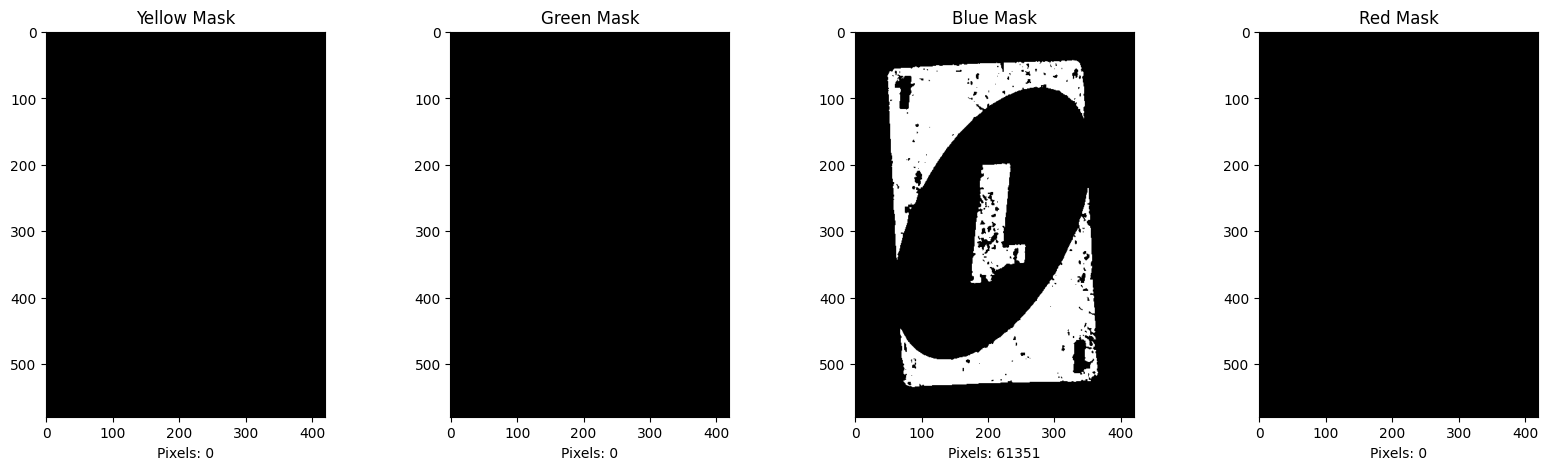

Card color: b


In [6]:
card_colour = get_card_colour(img_rgb, plot=True)
print("Card color:", card_colour)

In [7]:
def apply_colour_threshold(img_rgb: np.ndarray, color: str) -> np.ndarray:
    """
    Apply a threshold to the input image in rgb colorspace to extract objects of a specific color.

    """
    if color == 'b':
        img_th = apply_hsv_threshold(img_rgb, v_min = 0.75, s_min = 0.4, h_min=0.4, h_max=0.6)
    elif color == 'r':
        img_th = apply_hsv_threshold(img_rgb, v_min = 0.75, s_min = 0.5, h_min=0.97, h_max=0.05)
    elif color == 'y':
        img_th = apply_hsv_threshold(img_rgb, v_min = 0.75, s_min = 0.5, h_min=0.1, h_max=0.2)
    elif color == 'g':
        img_th = apply_hsv_threshold(img_rgb, v_min = 0.5, v_max = 0.8, s_min = 0.3, h_min=0.25, h_max=0.4)
    elif color == 'k':
        img_th = apply_hsv_threshold(img_rgb, s_min = 0.4)
    else:
        raise ValueError("Color must be one of 'r', 'g', 'b', or 'y', 'k'")
    return img_th

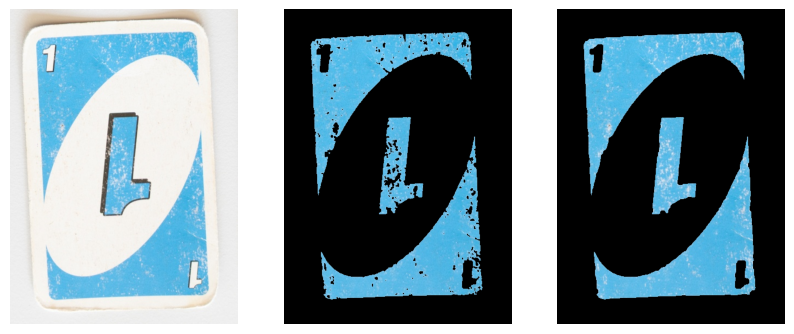

In [8]:

# apply a threshold to the image
img_thresholded = apply_colour_threshold(img_rgb, color=card_colour)

# plot the mask and the thresholded image side by side
plt.figure(figsize=(10, 5))

# mask
plt.subplot(1, 3, 1)
plt.imshow(img_rgb)
plt.axis("off")

# threshold image
plt.subplot(1, 3, 2)
plt.imshow(img_rgb * img_thresholded[..., None])
plt.axis("off")

# fill holes in the mask

from utils.lab_utils import remove_holes, apply_closing

disk_size = 5.5
if get_card_colour == 'k':
    disk_size = 3
img_thresholded_filled = apply_closing(img_thresholded, disk_size=disk_size)

# threshold image

img_th = img_rgb * img_thresholded_filled[..., None]
plt.subplot(1, 3, 3)
plt.imshow(img_th)
plt.axis("off")

plt.show()

In [9]:
# Get the contour of the card and show all contours on the original image, including hole contours

from utils.lab_utils import find_contours

def find_contours_in_image(img_thresholded: np.ndarray, img_rgb: np.ndarray, plot_contours=False):

    # Use the unfilled mask so internal holes are still present as contours.
    contours = find_contours(img_thresholded, n=11)[0]

    if plot_contours:
        # display all contours on a blank image
        img_contour = np.zeros_like(img_rgb)
        cv2.drawContours(img_contour, contours, -1, (256,256,256), 2)

        plt.figure(figsize=(8, 8))
        plt.imshow(img_contour)
        plt.axis("off")
        plt.title(f"Contours found, including holes: {len(contours)}")
        plt.show()

    return contours

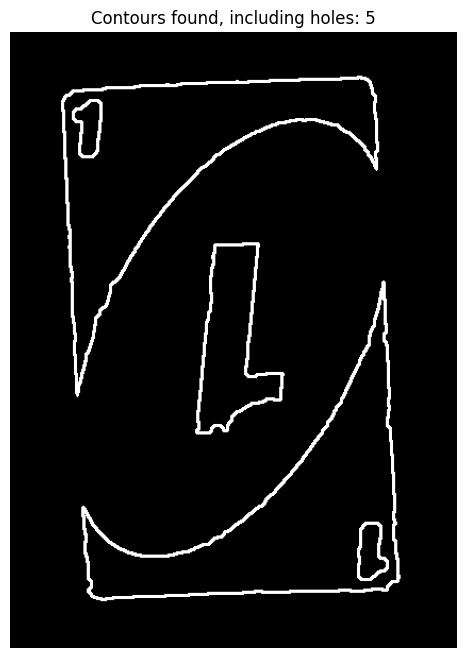

In [10]:
img_contours = find_contours_in_image(img_thresholded_filled, img_rgb, plot_contours=True)


In [11]:
# iterate through cards in data/reference_images/cropped

input_dir = "data/reference_images/cropped"

output_dir = "data/reference_images"
os.makedirs(output_dir, exist_ok=True)

threshold_dir = os.path.join(output_dir, "thresholded")
os.makedirs(threshold_dir, exist_ok=True)

mask_dir = os.path.join(output_dir, "mask")
os.makedirs(mask_dir, exist_ok=True)

contour_dir = os.path.join(output_dir, "contours")
os.makedirs(contour_dir, exist_ok=True)


valid_ext = (".jpg", ".jpeg", ".png")
filenames = sorted(
    f for f in os.listdir(input_dir)
    if f.lower().endswith(valid_ext) and not f.lower().endswith("_th.png")
)

for filename in filenames:
    img_path = os.path.join(input_dir, filename)
    img_bgr = cv2.imread(img_path)
    if img_bgr is None:
        print(f"Skipping unreadable file: {filename}")
        continue

    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    # Use a smaller preview for color classification to reduce runtime.
    preview_rgb = cv2.resize(img_rgb, None, fx=0.35, fy=0.35, interpolation=cv2.INTER_AREA)
    card_colour = get_card_colour(preview_rgb)

    img_thresholded = apply_colour_threshold(img_rgb, color=card_colour)

    disk_size = 3 if card_colour == 'k' else 5.5
    img_thresholded_filled = apply_closing(img_thresholded, disk_size=disk_size)

    # Keep image in uint8 range [0, 255] without re-scaling overflow.
    img_result_rgb = (img_rgb * img_thresholded_filled[..., None]).astype(np.uint8)

    # OpenCV writes BGR, so convert from RGB before saving.
    img_result_bgr = cv2.cvtColor(img_result_rgb, cv2.COLOR_RGB2BGR)

    stem, _ = os.path.splitext(filename)
    output_path = os.path.join(output_dir, f"thresholded/{stem}_th.png")
    cv2.imwrite(output_path, img_result_bgr)

    img_mask_bgr = cv2.cvtColor(img_thresholded_filled.astype(np.uint8) * 255, cv2.COLOR_GRAY2BGR)
    mask_path = os.path.join(output_dir, f"mask/{stem}_mask.png")
    cv2.imwrite(mask_path, img_mask_bgr)

    # compute and save the contours
    contours = find_contours(img_thresholded_filled, n=11)[0]
    # save the contours as a white line on blank image
    img_contours_bgr = np.zeros_like(img_bgr)
    cv2.drawContours(img_contours_bgr, contours, -1, (255,255,255), 2)
    contour_path = os.path.join(output_dir, f"contours/{stem}_contours.png")
    cv2.imwrite(contour_path, img_contours_bgr)


print(f"Saved {len(filenames)} thresholded images to {output_dir}")

Saved 54 thresholded images to data/reference_images


In [13]:
noisy_scene_test_path = "data/test_images/L1000957.jpg"

# do hsv thresholding on the test image and show the result
""" noisy_scene_test = cv2.imread(noisy_scene_test_path)
noisy_scene_test_rgb = cv2.cvtColor(noisy_scene_test, cv2.COLOR_BGR2RGB)   

plot_colors_histo(noisy_scene_test_rgb, func=extract_hsv_channels, labels=["Hue", "Saturation", "Value"])

test_thresholded = apply_hsv_threshold(noisy_scene_test_rgb, h_min=0.97, h_max=0.05, s_min=0.7)

# plot the mask and the thresholded image side by side
plt.figure(figsize=(10, 5))
# mask
plt.subplot(1, 2, 1)
plt.imshow(test_thresholded)
plt.axis("off")
# threshold image
plt.subplot(1, 2, 2)
plt.imshow(noisy_scene_test_rgb * test_thresholded[..., None])
plt.axis("off") """

' noisy_scene_test = cv2.imread(noisy_scene_test_path)\nnoisy_scene_test_rgb = cv2.cvtColor(noisy_scene_test, cv2.COLOR_BGR2RGB)   \n\nplot_colors_histo(noisy_scene_test_rgb, func=extract_hsv_channels, labels=["Hue", "Saturation", "Value"])\n\ntest_thresholded = apply_hsv_threshold(noisy_scene_test_rgb, h_min=0.97, h_max=0.05, s_min=0.7)\n\n# plot the mask and the thresholded image side by side\nplt.figure(figsize=(10, 5))\n# mask\nplt.subplot(1, 2, 1)\nplt.imshow(test_thresholded)\nplt.axis("off")\n# threshold image\nplt.subplot(1, 2, 2)\nplt.imshow(noisy_scene_test_rgb * test_thresholded[..., None])\nplt.axis("off") '

In [14]:
# testing the function on the test image